# Corona NLP — Tweet Sentiment Classification
### A beginner text classification project using Python & scikit-learn


## Step 1 — Import Libraries

In [1]:
import pandas as pd                
import numpy as np                
import re                          
import matplotlib.pyplot as plt    
import seaborn as sns              
from wordcloud import WordCloud    

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2 — Load the Dataset

In [3]:
# Load training and test files
# encoding='latin-1' handles special characters in the tweets
train = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')
test  = pd.read_csv('Corona_NLP_test.csv',  encoding='latin-1')

print("Training rows:", len(train))
print("Test rows:    ", len(test))
train.head()

Training rows: 41157
Test rows:     3798


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [4]:
# The two columns we care about:
# 'OriginalTweet' = the tweet text  (our input)
# 'Sentiment'     = the label       (what we want to predict)

print("Unique sentiment labels:")
print(train['Sentiment'].unique())

Unique sentiment labels:
['Neutral' 'Positive' 'Extremely Negative' 'Negative' 'Extremely Positive']


In [5]:
# Check for missing values
print("Missing values in training set:")
print(train[['OriginalTweet', 'Sentiment']].isnull().sum())

Missing values in training set:
OriginalTweet    0
Sentiment        0
dtype: int64



## Step 3 — Explore the Data (EDA)

In [6]:
print(train['Sentiment'].value_counts())

Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64


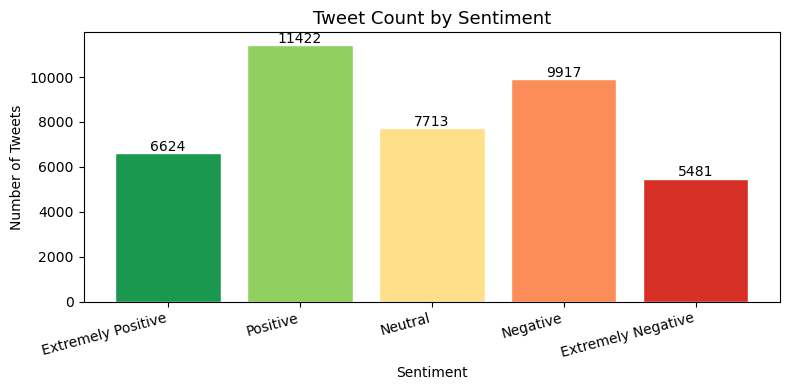

In [7]:
# Plot the sentiment distribution
order = ['Extremely Positive', 'Positive', 'Neutral', 'Negative', 'Extremely Negative']
colors = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']

plt.figure(figsize=(8, 4))
counts = train['Sentiment'].value_counts().reindex(order)
plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
plt.title('Tweet Count by Sentiment', fontsize=13)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
# Look at some example tweets from each group
for sentiment in order:
    example = train[train['Sentiment'] == sentiment]['OriginalTweet'].iloc[0]
    print(f"[{sentiment}]")
    print(f"  {example[:120]}")
    print()

[Extremely Positive]
  Due to the Covid-19 situation, we have increased demand for all food products. 

The wait time may be longer for all

[Positive]
  advice Talk to your neighbours family to exchange phone numbers create contact list with phone numbers of neighbours sch

[Neutral]
  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa and https://t.co/xX6ghGFzCC and https://t.co/I2NlzdxNo8

[Negative]
  For corona prevention,we should stop to buy things with the cash and should use online payment methods because corona ca

[Extremely Negative]
  Me, ready to go at supermarket during the #COVID19 outbreak.

Not because I'm paranoid, but because my food stock is



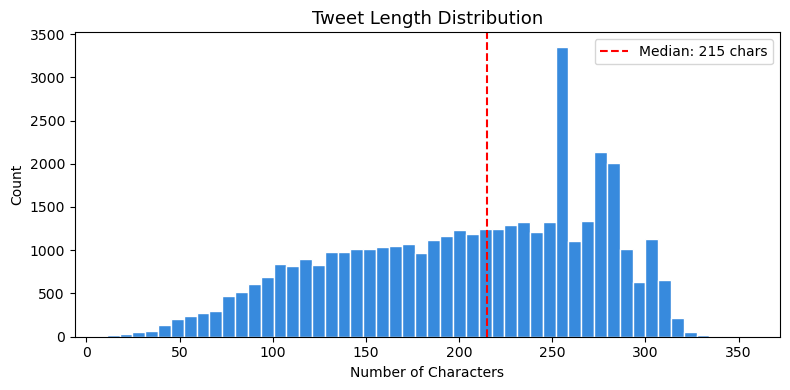

In [9]:
# How long are the tweets?
train['tweet_length'] = train['OriginalTweet'].apply(len)

plt.figure(figsize=(8, 4))
plt.hist(train['tweet_length'], bins=50, color='#378ADD', edgecolor='white')
plt.title('Tweet Length Distribution', fontsize=13)
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.axvline(train['tweet_length'].median(), color='red',
            linestyle='--', label=f"Median: {int(train['tweet_length'].median())} chars")
plt.legend()
plt.tight_layout()
plt.show()

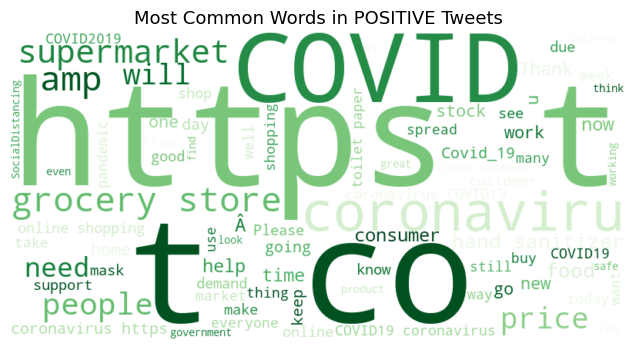

In [10]:
# Word Cloud for POSITIVE tweets
pos_text = ' '.join(train[train['Sentiment'].isin(['Positive', 'Extremely Positive'])]['OriginalTweet'])

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Greens', max_words=80).generate(pos_text)
plt.figure(figsize=(10, 4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in POSITIVE Tweets', fontsize=13)
plt.show()

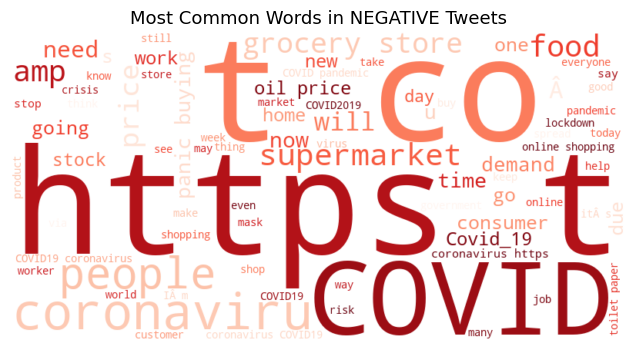

In [11]:
# Word Cloud for NEGATIVE tweets
neg_text = ' '.join(train[train['Sentiment'].isin(['Negative', 'Extremely Negative'])]['OriginalTweet'])

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Reds', max_words=80).generate(neg_text)
plt.figure(figsize=(10, 4))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in NEGATIVE Tweets', fontsize=13)
plt.show()

## Step 4 — Clean the Text

Tweets are messy — they have @mentions, #hashtags, links, and emojis.  
We strip all of that so the model focuses on the actual words.

In [12]:
def clean_tweet(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()                          # make lowercase
    text = re.sub(r'http\S+', '', text)          # remove links
    text = re.sub(r'@\w+', '', text)             # remove @mentions
    text = re.sub(r'#\w+', '', text)             # remove #hashtags
    text = re.sub(r'[^a-z\s]', '', text)         # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

# Apply to both train and test
train['clean_tweet'] = train['OriginalTweet'].apply(clean_tweet)
test['clean_tweet']  = test['OriginalTweet'].apply(clean_tweet)

# See before and after
print("BEFORE:", train['OriginalTweet'].iloc[1])
print()
print("AFTER: ", train['clean_tweet'].iloc[1])

BEFORE: advice Talk to your neighbours family to exchange phone numbers create contact list with phone numbers of neighbours schools employer chemist GP set up online shopping accounts if poss adequate supplies of regular meds but not over order

AFTER:  advice talk to your neighbours family to exchange phone numbers create contact list with phone numbers of neighbours schools employer chemist gp set up online shopping accounts if poss adequate supplies of regular meds but not over order


## Step 5 — Prepare Data for the Model

We have 5 sentiment classes. We need to:
1. Convert the labels to numbers
2. Convert the tweet text to numbers using TF-IDF

In [13]:
# Map the 5 sentiment labels to numbers
label_map = {
    'Extremely Negative': 0,
    'Negative':           1,
    'Neutral':            2,
    'Positive':           3,
    'Extremely Positive': 4
}

train['label'] = train['Sentiment'].map(label_map)
test['label']  = test['Sentiment'].map(label_map)

print("Label mapping:")
for k, v in label_map.items():
    print(f"  {v} = {k}")

Label mapping:
  0 = Extremely Negative
  1 = Negative
  2 = Neutral
  3 = Positive
  4 = Extremely Positive


In [14]:
# Input (X) and target (y)
X_train = train['clean_tweet']
y_train = train['label']

X_test  = test['clean_tweet']
y_test  = test['label']

print("Training tweets:", len(X_train))
print("Test tweets:    ", len(X_test))

Training tweets: 41157
Test tweets:     3798


In [15]:
# Convert text to numbers using TF-IDF
# This turns each tweet into a row of numbers the model can understand
tfidf = TfidfVectorizer(
    max_features=10000,    # use the top 10,000 most important words
    ngram_range=(1, 2)     # use single words AND two-word phrases (e.g. 'social distancing')
)

X_train_tfidf = tfidf.fit_transform(X_train)   # learn vocab from training data
X_test_tfidf  = tfidf.transform(X_test)         # apply same vocab to test data

print("Training matrix shape:", X_train_tfidf.shape)
# (rows = tweets, columns = words/phrases)

Training matrix shape: (41157, 10000)


## Step 6 — Train the Model

In [17]:
# Logistic Regression works well for text classification
# class_weight='balanced' helps because some sentiments have more tweets than others
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model trained!")

Model trained!


In [18]:
# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 54.19%


## Step 7 — Evaluate the Results

In [19]:
# Full report — one row per sentiment class
label_names = ['Extremely Negative', 'Negative', 'Neutral', 'Positive', 'Extremely Positive']

print(classification_report(y_test, y_pred, target_names=label_names))

                    precision    recall  f1-score   support

Extremely Negative       0.53      0.66      0.59       592
          Negative       0.53      0.38      0.44      1041
           Neutral       0.53      0.76      0.63       619
          Positive       0.54      0.39      0.45       947
Extremely Positive       0.58      0.71      0.64       599

          accuracy                           0.54      3798
         macro avg       0.54      0.58      0.55      3798
      weighted avg       0.54      0.54      0.53      3798



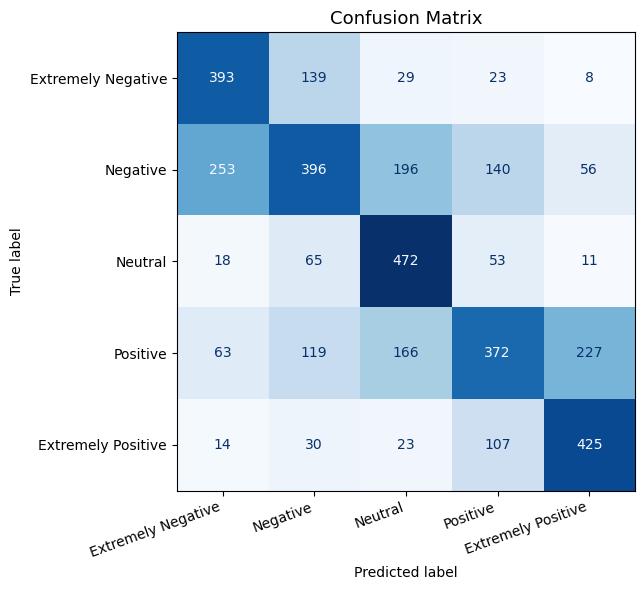

In [20]:
# Confusion Matrix
# Each row = actual label, each column = predicted label
# The diagonal = correct predictions

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', colorbar=False, ax=ax)
plt.title('Confusion Matrix', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

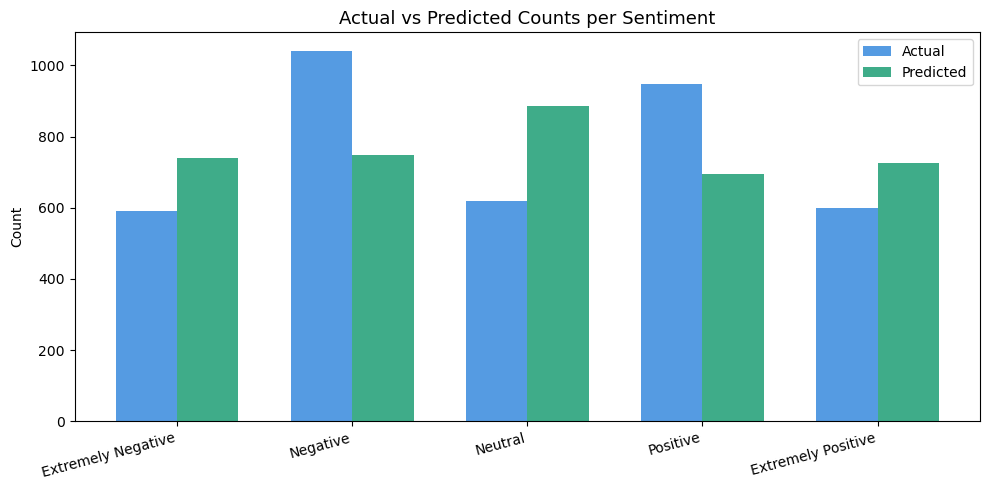

In [21]:
# Compare actual vs predicted counts visually
actual_counts    = pd.Series(y_test).map({v:k for k,v in label_map.items()}).value_counts().reindex(label_names)
predicted_counts = pd.Series(y_pred).map({v:k for k,v in label_map.items()}).value_counts().reindex(label_names)

x = np.arange(len(label_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, actual_counts.values,    width, label='Actual',    color='#378ADD', alpha=0.85)
plt.bar(x + width/2, predicted_counts.values, width, label='Predicted', color='#1D9E75', alpha=0.85)
plt.xticks(x, label_names, rotation=15, ha='right')
plt.ylabel('Count')
plt.title('Actual vs Predicted Counts per Sentiment', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

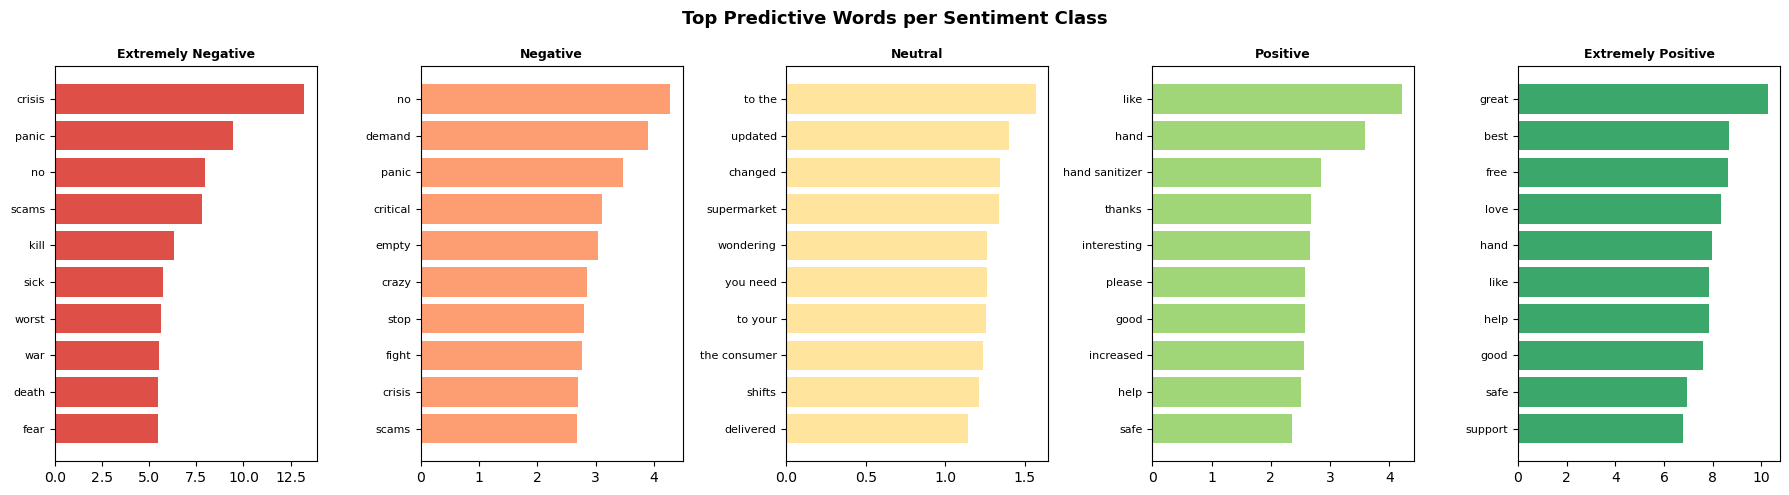

In [22]:
# Top words for each sentiment class
# Each class has its own set of coefficients in logistic regression

feature_names = tfidf.get_feature_names_out()
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colors = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']

for i, (ax, label, color) in enumerate(zip(axes, label_names, colors)):
    coefs = model.coef_[i]
    top_idx = coefs.argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = [coefs[j] for j in top_idx]
    ax.barh(top_words[::-1], top_vals[::-1], color=color, alpha=0.85)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top Predictive Words per Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8 — Predict on New Tweets!

In [23]:
# Reverse map so we can show the label name instead of a number
reverse_map = {v: k for k, v in label_map.items()}

def predict_tweet(tweet_text):
    cleaned  = clean_tweet(tweet_text)
    features = tfidf.transform([cleaned])
    pred     = model.predict(features)[0]
    probs    = model.predict_proba(features)[0]
    label    = reverse_map[pred]
    confidence = probs[pred] * 100

    print(f"Tweet:      '{tweet_text}'")
    print(f"Prediction: {label}  ({confidence:.1f}% confident)")
    print()

In [24]:
# Try some example tweets!
predict_tweet("The vaccines are working, cases are going down. So grateful for the scientists!")
predict_tweet("Lost my job because of lockdown. This is a disaster.")
predict_tweet("Government announced new COVID restrictions starting next week.")
predict_tweet("Panic buying toilet paper again?? People need to calm down!!")
predict_tweet("Stay home, stay safe, we will get through this together!")

Tweet:      'The vaccines are working, cases are going down. So grateful for the scientists!'
Prediction: Neutral  (32.0% confident)

Tweet:      'Lost my job because of lockdown. This is a disaster.'
Prediction: Extremely Negative  (58.1% confident)

Tweet:      'Government announced new COVID restrictions starting next week.'
Prediction: Neutral  (85.2% confident)

Tweet:      'Panic buying toilet paper again?? People need to calm down!!'
Prediction: Negative  (54.1% confident)

Tweet:      'Stay home, stay safe, we will get through this together!'
Prediction: Positive  (57.1% confident)



In [25]:
# Try YOUR OWN tweet here!
my_tweet = "Type your own COVID tweet here and see what the model thinks!"
predict_tweet(my_tweet)

Tweet:      'Type your own COVID tweet here and see what the model thinks!'
Prediction: Neutral  (69.7% confident)

